In [1]:
import tensorflow_advanced_segmentation_models as tasm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from __future__ import division
from utils import file
from tensorflow.keras.layers import Input, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, Concatenate, Activation, Add, multiply, add, concatenate, LeakyReLU, ZeroPadding2D, UpSampling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K 
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

TRAINING_IMAGE_PATH = 'training/images'
TRAINING_MASK_PATH = 'training/masks'
trainingImagePaths = file.getSortedFilePaths(TRAINING_IMAGE_PATH)
trainingMaskPaths = file.getSortedFilePaths(TRAINING_MASK_PATH)
trainDataset = file.datasetGenerator(trainingImagePaths, trainingMaskPaths, 'channels_first')
trainDataset

TESTING_IMAGE_PATH = 'testing/images'
TESTING_MASK_PATH = 'testing/masks'
testingImagePaths = file.getSortedFilePaths(TESTING_IMAGE_PATH)
testingMaskPaths = file.getSortedFilePaths(TESTING_MASK_PATH)
testDataset = file.datasetGenerator(testingImagePaths, testingMaskPaths, 'channels_first')
testDataset

def AttnBlock2D(x, g, inter_channel, data_format='channels_first'):

    theta_x = Conv2D(inter_channel, [1, 1], strides=[1, 1], data_format=data_format)(x)

    phi_g = Conv2D(inter_channel, [1, 1], strides=[1, 1], data_format=data_format)(g)

    f = Activation('relu')(add([theta_x, phi_g]))

    psi_f = Conv2D(1, [1, 1], strides=[1, 1], data_format=data_format)(f)

    rate = Activation('sigmoid')(psi_f)

    att_x = multiply([x, rate])

    return att_x


def attention_up_and_concate(down_layer, layer, data_format='channels_first'):
    
    if data_format == 'channels_first':
        in_channel = down_layer.get_shape().as_list()[1]
    else:
        in_channel = down_layer.get_shape().as_list()[3]
    
    up = UpSampling2D(size=(2, 2), data_format=data_format)(down_layer)
    layer = AttnBlock2D(x=layer, g=up, inter_channel=in_channel // 4, data_format=data_format)

    if data_format == 'channels_first':
        my_concat = Lambda(lambda x: K.concatenate([x[0], x[1]], axis=1))
    else:
        my_concat = Lambda(lambda x: K.concatenate([x[0], x[3]], axis=3))
    
    concate = my_concat([up, layer])
    return concate

# Attention U-Net 
def att_unet(img_w, img_h, n_label, data_format='channels_first'):
    inputs = Input((3, img_w, img_h))
    x = inputs
    depth = 4
    features = 32
    skips = []
    for i in range(depth):

        # ENCODER
        x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
        x = Dropout(0.2)(x)
        x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
        skips.append(x)
        x = MaxPooling2D((2, 2), data_format='channels_first')(x)
        features = features * 2

    # BOTTLENECK
    x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
    x = Dropout(0.2)(x)
    x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)

    # DECODER
    for i in reversed(range(depth)):
        features = features // 2
        x = attention_up_and_concate(x, skips[i], data_format=data_format)
        x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
        x = Dropout(0.2)(x)
        x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
    
    conv6 = Conv2D(n_label, (1, 1), padding='same', data_format=data_format)(x)
    conv7 = Activation('sigmoid')(conv6)
    
    model = Model(inputs=inputs, outputs=conv7)

    return model

In [11]:
model = att_unet(img_h=256, img_w=256, n_label = 1);

model.compile(optimizer = Adam(lr = 1e-4), loss = tasm.losses.BinaryFocalLoss(), metrics = ['accuracy', tasm.metrics.FScore(), tasm.metrics.IOUScore()])

current_loss = "focal"

class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, model, epoch_interval=2):
        self.dataset = dataset
        self.epoch_interval = epoch_interval
        self.best_val_score = 0.0
        self.model = model
    
    def display(self, display_list, extra_title=''):
        plt.figure(figsize=(15, 15))
        title = ['Tikroji nuotrauka', 'Tikroji segmentacija', 'Segmentuota nuotrauka']

        if len(display_list) > len(title):
            title.append(extra_title)

        for i in range(len(display_list)):
            plt.subplot(1, len(display_list), i+1)
            plt.title(title[i])
            plt.imshow(display_list[i], cmap='gray')
            plt.axis('off')
        plt.show()
        
    def create_mask(self, pred_mask):
        pred_mask = (pred_mask > 0.5).astype("int32")
        return pred_mask[0]
    
    def show_predictions(self, dataset, num=2):
        for image, mask in dataset.take(num):
            pred_mask = self.model.predict(image)
            self.display([image[0], mask[0], self.create_mask(pred_mask)])
        
    def on_epoch_end(self, epoch, logs=None):
        # also save if validation error is smallest
        if 'f1-score' in logs.keys():
            val_score = logs['f1-score']
            if val_score > self.best_val_score:
                self.best_val_score = val_score
                print('New best weights found!')
                self.model.save_weights("./attention-unet-weights/" + current_loss + '/best_weights.hdf5')
        else:
            print('Key val_dice_eval does not exist!')

from keras.callbacks import ModelCheckpoint


mcp_save = ModelCheckpoint(
    './attention-unet-weights/' +  current_loss + '/weights.{epoch:02d}-{loss:.4f}.hdf5', save_best_only=False, save_weights_only=True, monitor='loss', verbose=1)

reduce_lr_loss = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=7, verbose=1, min_delta=1e-4, mode='min')

history = model.fit(trainDataset,
              batch_size=2,
              epochs=50,
              shuffle=True,
              verbose=1,
              validation_data=testDataset, callbacks=[mcp_save, reduce_lr_loss, DisplayCallback(trainDataset, model)] )

Epoch 1/50
      6/Unknown - 4s 76ms/step - loss: 0.1250 - accuracy: 0.0830 - f1-score: 0.0221 - iou_score: 0.0122WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0344s vs `on_train_batch_end` time: 0.0425s). Check your callbacks.
    323/Unknown - 28s 75ms/step - loss: 0.0183 - accuracy: 0.4112 - f1-score: 0.0251 - iou_score: 0.0135
Epoch 1: saving model to ./attention-unet-weights/focal\weights.01-0.0183.hdf5
New best weights found!
324/324 [==============================] - 32s 87ms/step - loss: 0.0183 - accuracy: 0.4107 - f1-score: 0.0253 - iou_score: 0.0136 - val_loss: 0.0161 - val_accuracy: 0.5545 - val_f1-score: 0.0275 - val_iou_score: 0.0151 - lr: 1.0000e-04
Epoch 2/50
323/324 [============================>.] - ETA: 0s - loss: 0.0101 - accuracy: 0.1993 - f1-score: 0.0281 - iou_score: 0.0152
Epoch 2: saving model to ./attention-unet-weights/focal\weights.02-0.0101.hdf5
New best weights found!
324/324 [=====================

In [12]:
import pandas as pd
history = model.history.history
history_df = pd.DataFrame(history)
history_df.to_csv('attention_unet_focal_history.csv', index=True)

model.load_weights("./attention-unet-weights/" +  current_loss + "/best_weights.hdf5")

scores = model.evaluate(testDataset)
print("Loss: {:.5}".format(scores[0]))
for metric, value in zip(["accuracy", tasm.metrics.FScore(), tasm.metrics.IOUScore()], scores[1:]):
    if metric != "accuracy":
        metric = metric.__name__
    print("mean {}: {:.5}".format(metric, value))

84/84 [==============================] - 4s 25ms/step - loss: 0.0065 - accuracy: 0.1637 - f1-score: 0.0725 - iou_score: 0.0494
Loss: 0.006532
mean accuracy: 0.16374
mean f1-score: 0.072469
mean iou_score: 0.049384


In [13]:
model = att_unet(img_h=256, img_w=256, n_label = 1);

model.compile(optimizer = Adam(lr = 1e-4), loss = tasm.losses.DiceLoss(), metrics = ['accuracy', tasm.metrics.FScore(), tasm.metrics.IOUScore()])

current_loss = "dice"

class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, model, epoch_interval=2):
        self.dataset = dataset
        self.epoch_interval = epoch_interval
        self.best_val_score = 0.0
        self.model = model
    
    def display(self, display_list, extra_title=''):
        plt.figure(figsize=(15, 15))
        title = ['Tikroji nuotrauka', 'Tikroji segmentacija', 'Segmentuota nuotrauka']

        if len(display_list) > len(title):
            title.append(extra_title)

        for i in range(len(display_list)):
            plt.subplot(1, len(display_list), i+1)
            plt.title(title[i])
            plt.imshow(display_list[i], cmap='gray')
            plt.axis('off')
        plt.show()
        
    def create_mask(self, pred_mask):
        pred_mask = (pred_mask > 0.5).astype("int32")
        return pred_mask[0]
    
    def show_predictions(self, dataset, num=2):
        for image, mask in dataset.take(num):
            pred_mask = self.model.predict(image)
            self.display([image[0], mask[0], self.create_mask(pred_mask)])
        
    def on_epoch_end(self, epoch, logs=None):
        # also save if validation error is smallest
        if 'f1-score' in logs.keys():
            val_score = logs['f1-score']
            if val_score > self.best_val_score:
                self.best_val_score = val_score
                print('New best weights found!')
                self.model.save_weights("./attention-unet-weights/" + current_loss + '/best_weights.hdf5')
        else:
            print('Key val_dice_eval does not exist!')

from keras.callbacks import ModelCheckpoint


mcp_save = ModelCheckpoint(
    './attention-unet-weights/' +  current_loss + '/weights.{epoch:02d}-{loss:.4f}.hdf5', save_best_only=False, save_weights_only=True, monitor='loss', verbose=1)

reduce_lr_loss = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=7, verbose=1, min_delta=1e-4, mode='min')

history = model.fit(trainDataset,
              batch_size=2,
              epochs=50,
              shuffle=True,
              verbose=1,
              validation_data=testDataset, callbacks=[mcp_save, reduce_lr_loss, DisplayCallback(trainDataset, model)] )

c:\Users\ITWORK\miniconda3\lib\site-packages\keras\optimizer_v2\adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


Epoch 1/50
      6/Unknown - 4s 74ms/step - loss: 0.9655 - accuracy: 0.0075 - f1-score: 0.0345 - iou_score: 0.0189WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0334s vs `on_train_batch_end` time: 0.0535s). Check your callbacks.
    323/Unknown - 26s 70ms/step - loss: 0.9605 - accuracy: 0.0659 - f1-score: 0.0395 - iou_score: 0.0227
Epoch 1: saving model to ./attention-unet-weights/dice\weights.01-0.9605.hdf5
New best weights found!
324/324 [==============================] - 30s 81ms/step - loss: 0.9605 - accuracy: 0.0659 - f1-score: 0.0394 - iou_score: 0.0226 - val_loss: 0.9642 - val_accuracy: 0.0725 - val_f1-score: 0.0357 - val_iou_score: 0.0209 - lr: 1.0000e-04
Epoch 2/50
323/324 [============================>.] - ETA: 0s - loss: 0.9606 - accuracy: 0.6341 - f1-score: 0.0394 - iou_score: 0.0226
Epoch 2: saving model to ./attention-unet-weights/dice\weights.02-0.9606.hdf5
324/324 [==============================] - 27s 80ms/step

In [14]:
import pandas as pd
history = model.history.history
history_df = pd.DataFrame(history)
history_df.to_csv('attention_unet_dice_history.csv', index=True)

model.load_weights("./attention-unet-weights/" +  current_loss + "/best_weights.hdf5")

scores = model.evaluate(testDataset)
print("Loss: {:.5}".format(scores[0]))
for metric, value in zip(["accuracy", tasm.metrics.FScore(), tasm.metrics.IOUScore()], scores[1:]):
    if metric != "accuracy":
        metric = metric.__name__
    print("mean {}: {:.5}".format(metric, value))

84/84 [==============================] - 3s 23ms/step - loss: 0.9656 - accuracy: 0.7560 - f1-score: 0.0343 - iou_score: 0.0199
Loss: 0.96561
mean accuracy: 0.75601
mean f1-score: 0.034266
mean iou_score: 0.019925


In [15]:
model = att_unet(img_h=256, img_w=256, n_label = 1);

model.compile(optimizer = Adam(lr = 1e-4), loss = tasm.losses.BinaryCELoss(), metrics = ['accuracy', tasm.metrics.FScore(), tasm.metrics.IOUScore()])

current_loss = "bce"

class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, model, epoch_interval=2):
        self.dataset = dataset
        self.epoch_interval = epoch_interval
        self.best_val_score = 0.0
        self.model = model
    
    def display(self, display_list, extra_title=''):
        plt.figure(figsize=(15, 15))
        title = ['Tikroji nuotrauka', 'Tikroji segmentacija', 'Segmentuota nuotrauka']

        if len(display_list) > len(title):
            title.append(extra_title)

        for i in range(len(display_list)):
            plt.subplot(1, len(display_list), i+1)
            plt.title(title[i])
            plt.imshow(display_list[i], cmap='gray')
            plt.axis('off')
        plt.show()
        
    def create_mask(self, pred_mask):
        pred_mask = (pred_mask > 0.5).astype("int32")
        return pred_mask[0]
    
    def show_predictions(self, dataset, num=2):
        for image, mask in dataset.take(num):
            pred_mask = self.model.predict(image)
            self.display([image[0], mask[0], self.create_mask(pred_mask)])
        
    def on_epoch_end(self, epoch, logs=None):
        # also save if validation error is smallest
        if 'f1-score' in logs.keys():
            val_score = logs['f1-score']
            if val_score > self.best_val_score:
                self.best_val_score = val_score
                print('New best weights found!')
                self.model.save_weights("./attention-unet-weights/" + current_loss + '/best_weights.hdf5')
        else:
            print('Key val_dice_eval does not exist!')

from keras.callbacks import ModelCheckpoint


mcp_save = ModelCheckpoint(
    './attention-unet-weights/' +  current_loss + '/weights.{epoch:02d}-{loss:.4f}.hdf5', save_best_only=False, save_weights_only=True, monitor='loss', verbose=1)

reduce_lr_loss = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=7, verbose=1, min_delta=1e-4, mode='min')

history = model.fit(trainDataset,
              batch_size=2,
              epochs=50,
              shuffle=True,
              verbose=1,
              validation_data=testDataset, callbacks=[mcp_save, reduce_lr_loss, DisplayCallback(trainDataset, model)] )

c:\Users\ITWORK\miniconda3\lib\site-packages\keras\optimizer_v2\adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


Epoch 1/50
      6/Unknown - 4s 77ms/step - loss: 0.6791 - accuracy: 0.0280 - f1-score: 0.0281 - iou_score: 0.0158WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0342s vs `on_train_batch_end` time: 0.0475s). Check your callbacks.
    323/Unknown - 27s 74ms/step - loss: 0.1486 - accuracy: 0.2299 - f1-score: 0.0127 - iou_score: 0.0066
Epoch 1: saving model to ./attention-unet-weights/bce\weights.01-0.1484.hdf5
New best weights found!
324/324 [==============================] - 31s 86ms/step - loss: 0.1484 - accuracy: 0.2308 - f1-score: 0.0127 - iou_score: 0.0066 - val_loss: 0.1410 - val_accuracy: 0.6790 - val_f1-score: 0.0209 - val_iou_score: 0.0111 - lr: 1.0000e-04
Epoch 2/50
323/324 [============================>.] - ETA: 0s - loss: 0.1051 - accuracy: 0.1658 - f1-score: 0.0133 - iou_score: 0.0069
Epoch 2: saving model to ./attention-unet-weights/bce\weights.02-0.1050.hdf5
New best weights found!
324/324 [=========================

In [16]:
import pandas as pd
history = model.history.history
history_df = pd.DataFrame(history)
history_df.to_csv('attention_unet_bce_history.csv', index=True)

model.load_weights("./attention-unet-weights/" +  current_loss + "/best_weights.hdf5")

scores = model.evaluate(testDataset)
print("Loss: {:.5}".format(scores[0]))
for metric, value in zip(["accuracy", tasm.metrics.FScore(), tasm.metrics.IOUScore()], scores[1:]):
    if metric != "accuracy":
        metric = metric.__name__
    print("mean {}: {:.5}".format(metric, value))

84/84 [==============================] - 4s 25ms/step - loss: 0.0789 - accuracy: 0.2944 - f1-score: 0.1131 - iou_score: 0.0962
Loss: 0.078928
mean accuracy: 0.29444
mean f1-score: 0.11306
mean iou_score: 0.096179


84/84 [==============================] - 4s 23ms/step - loss: 0.9276 - accuracy: 0.1637 - f1-score: 0.0725 - iou_score: 0.0494
Loss: 0.92762
mean accuracy: 0.16374
mean f1-score: 0.072469
mean iou_score: 0.049384


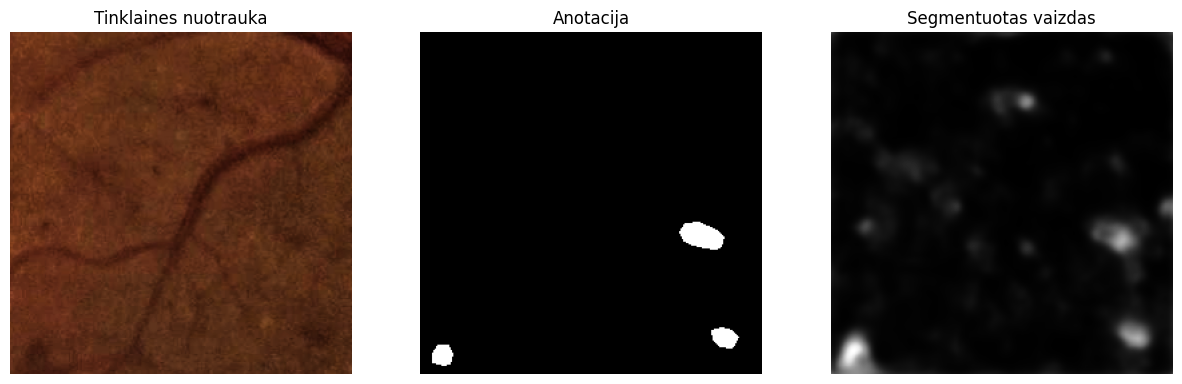

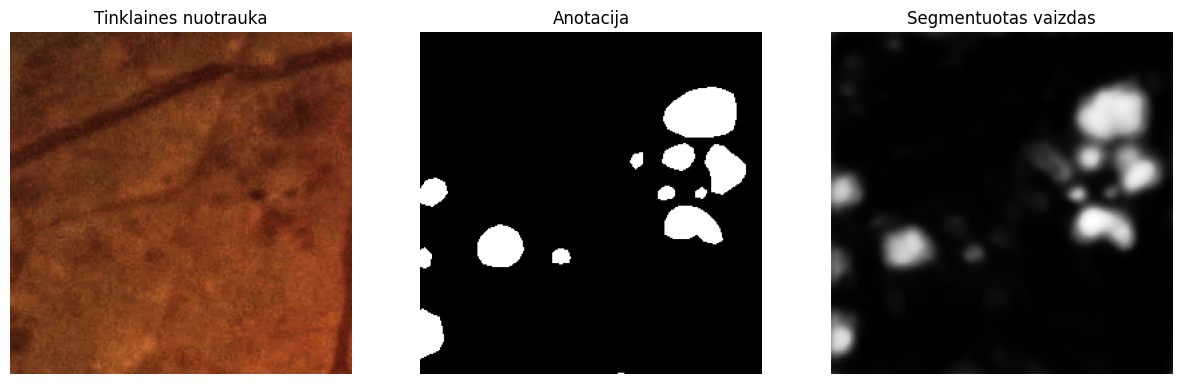

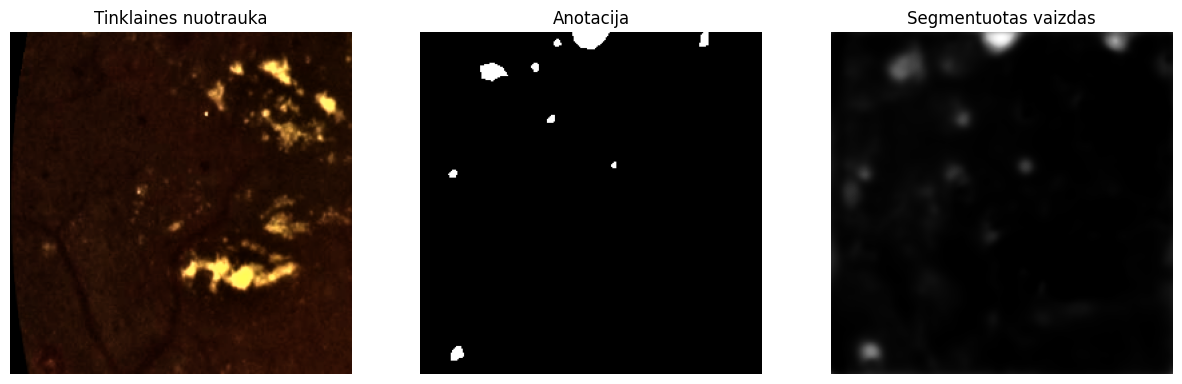

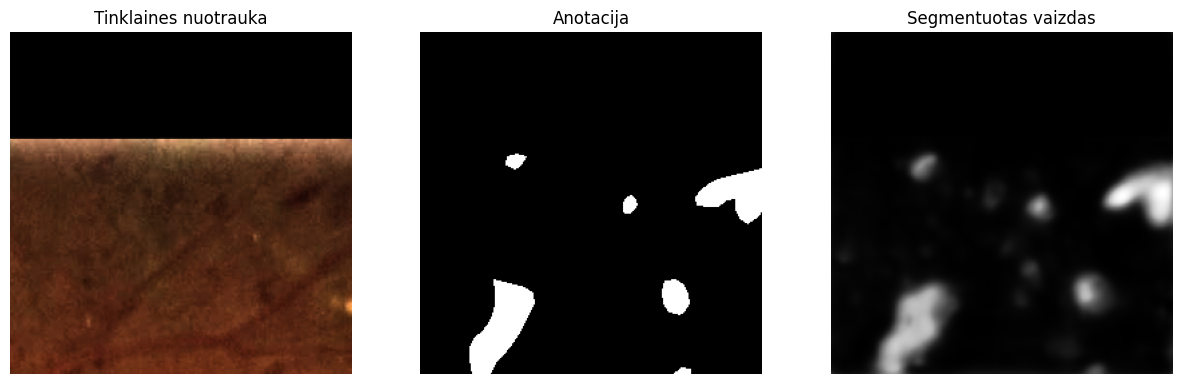

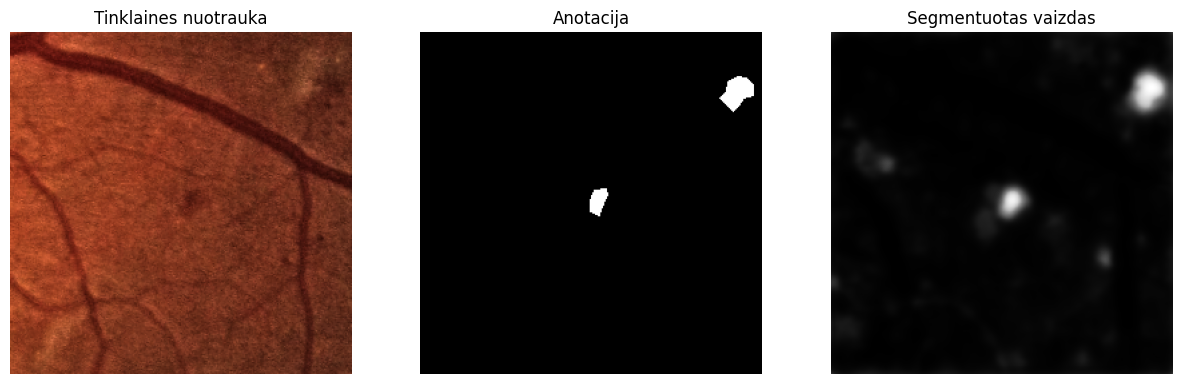

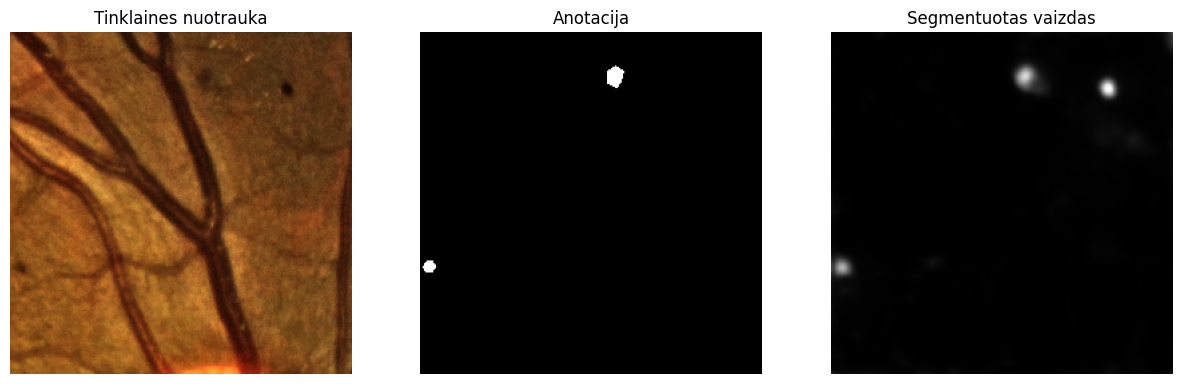

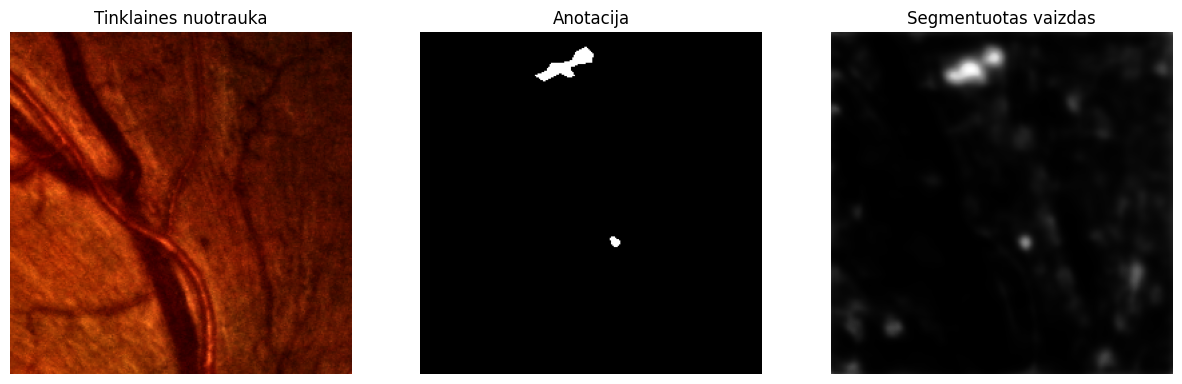

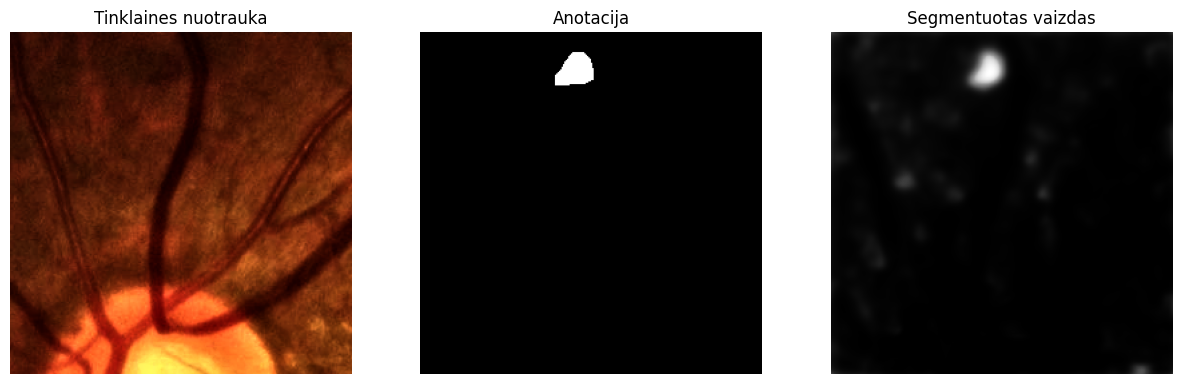

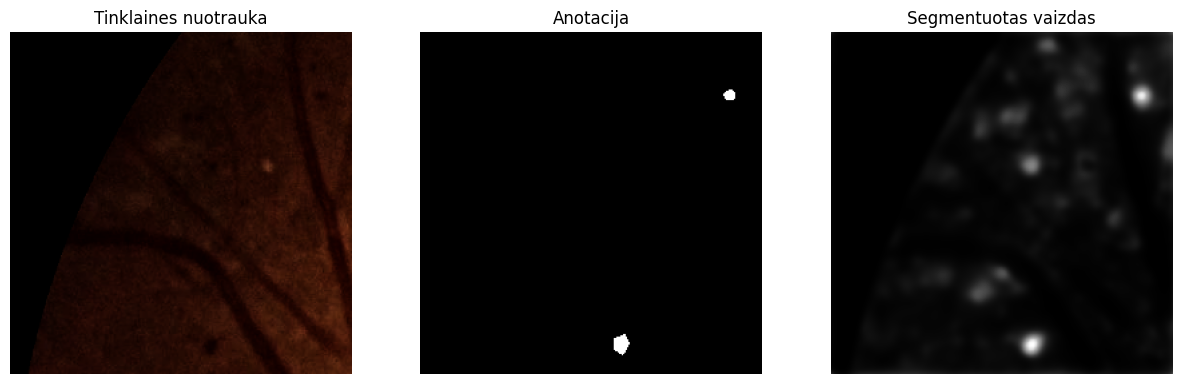

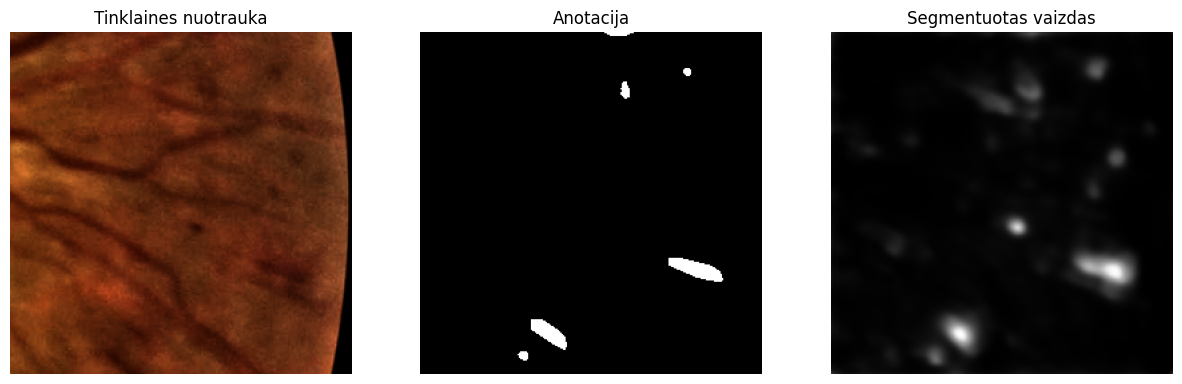

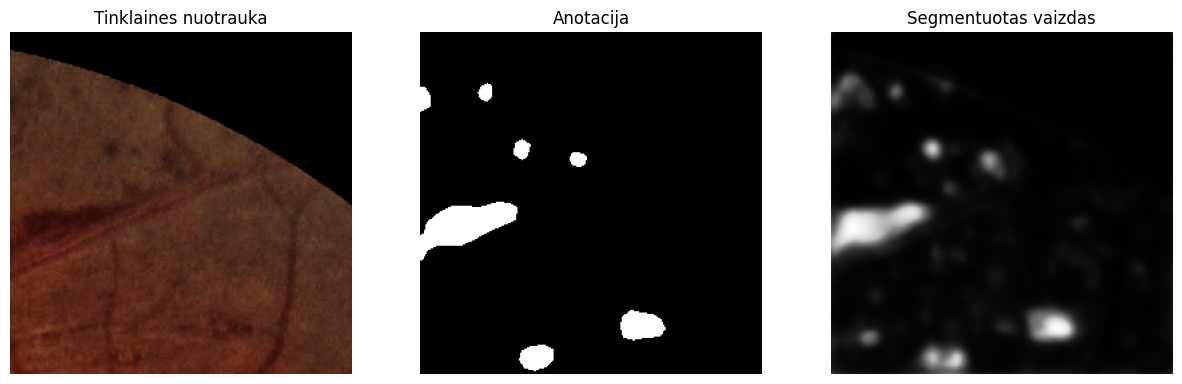

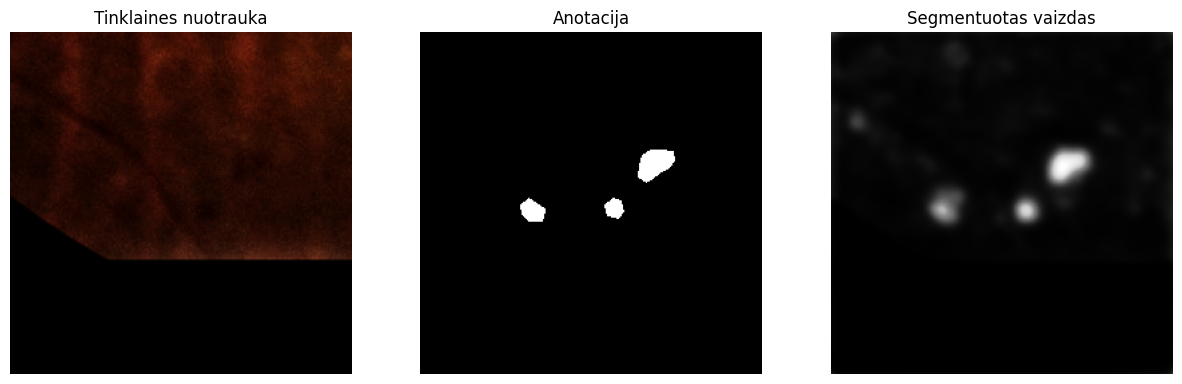

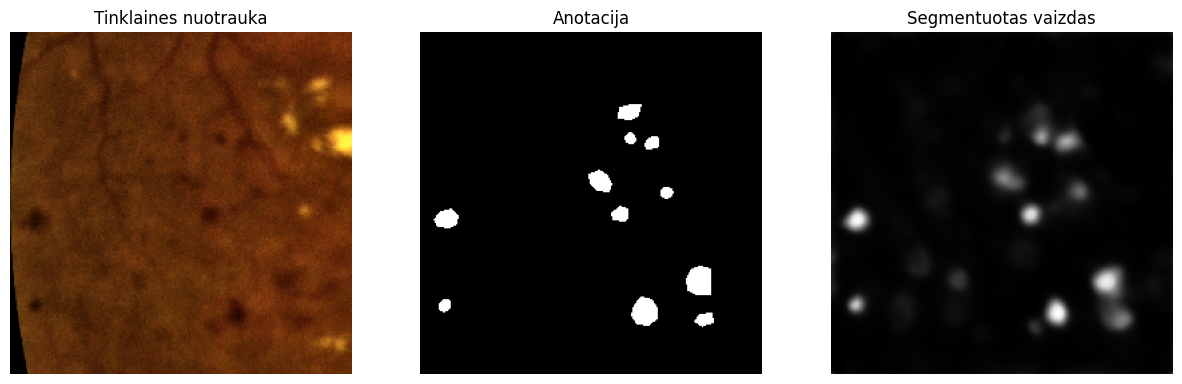

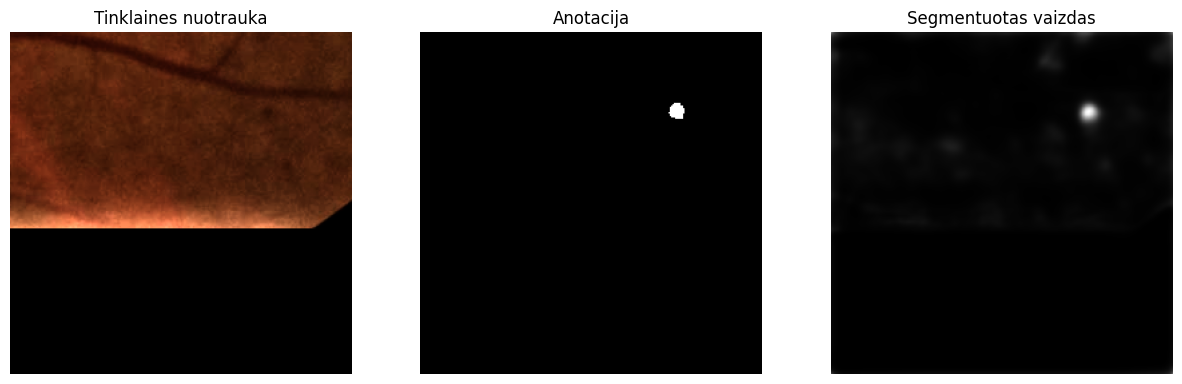

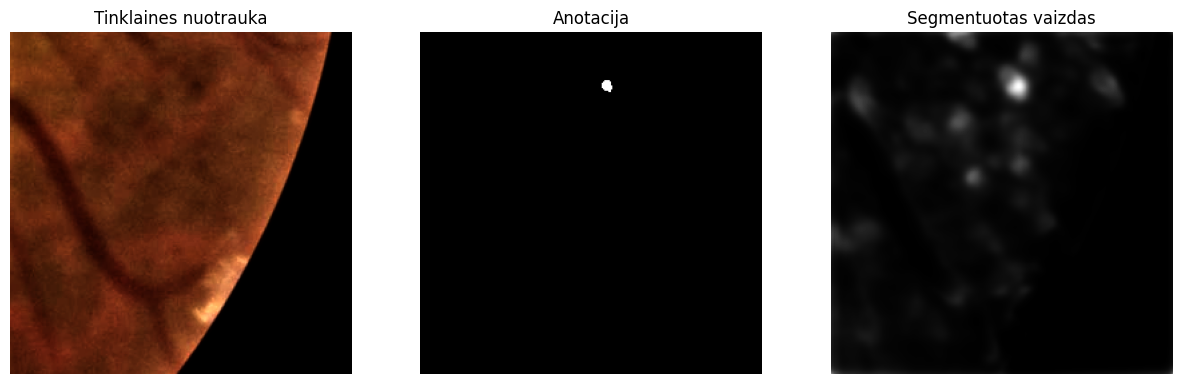

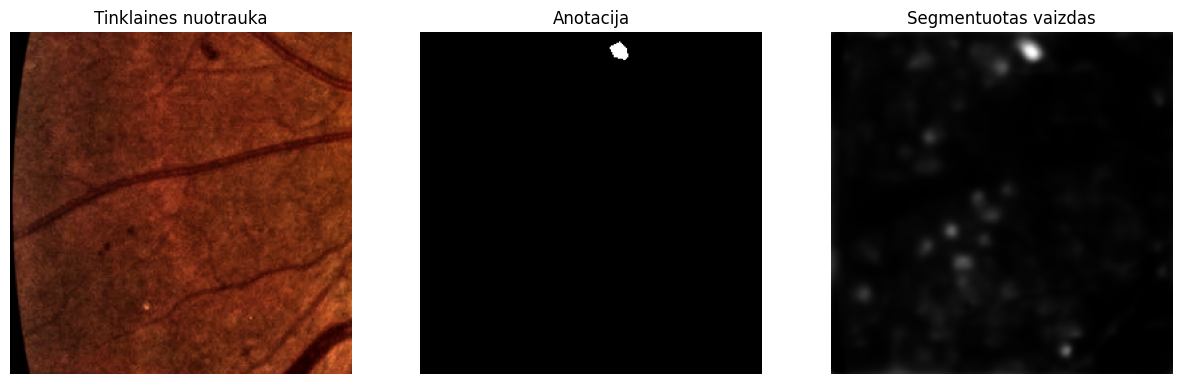

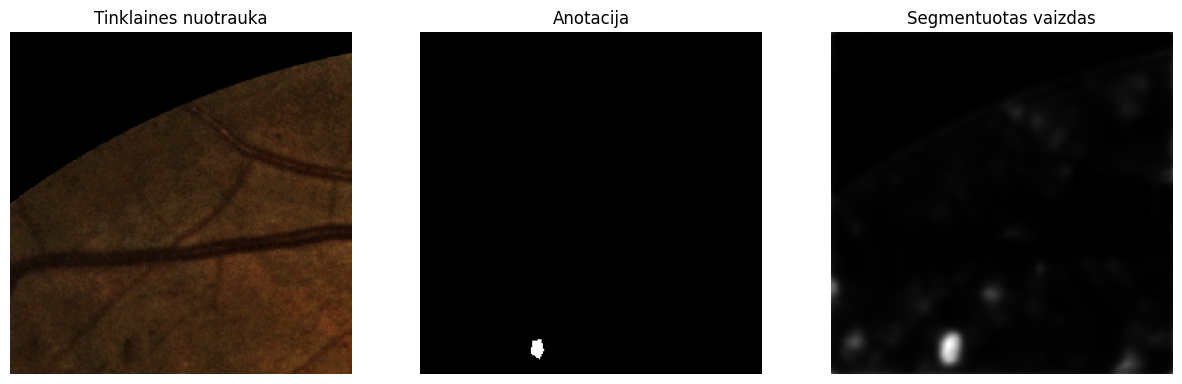

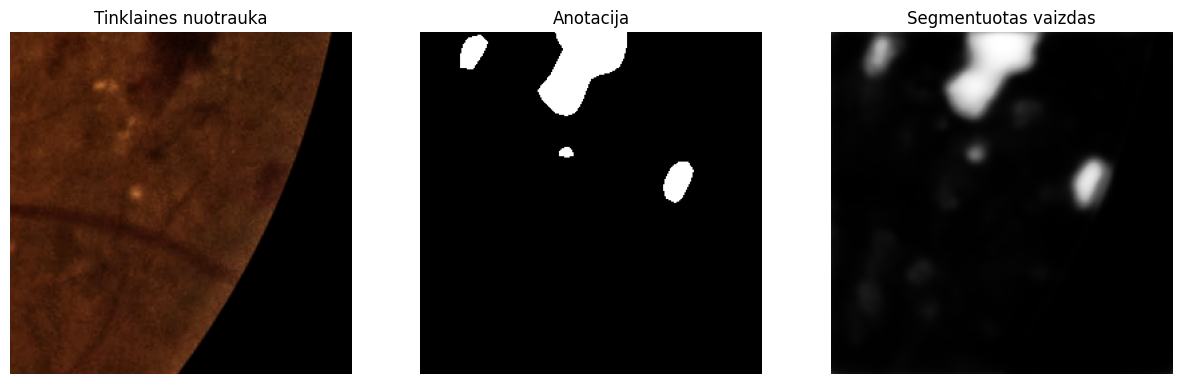

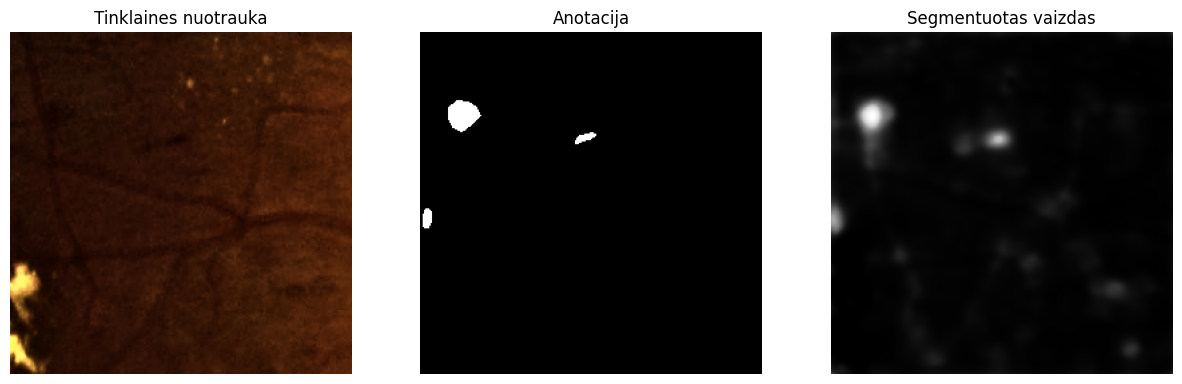

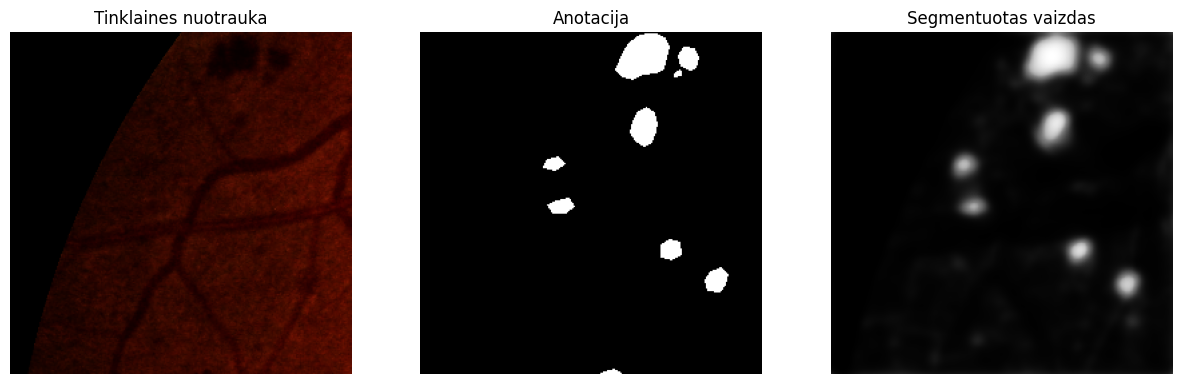

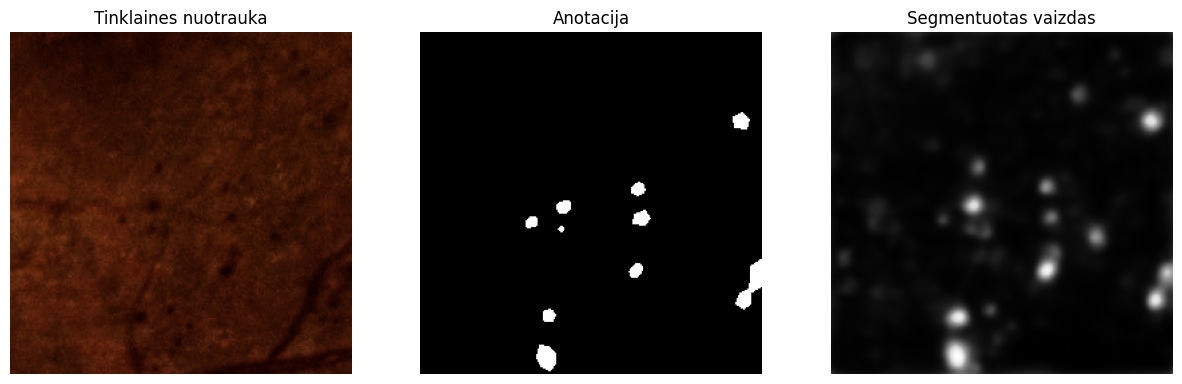

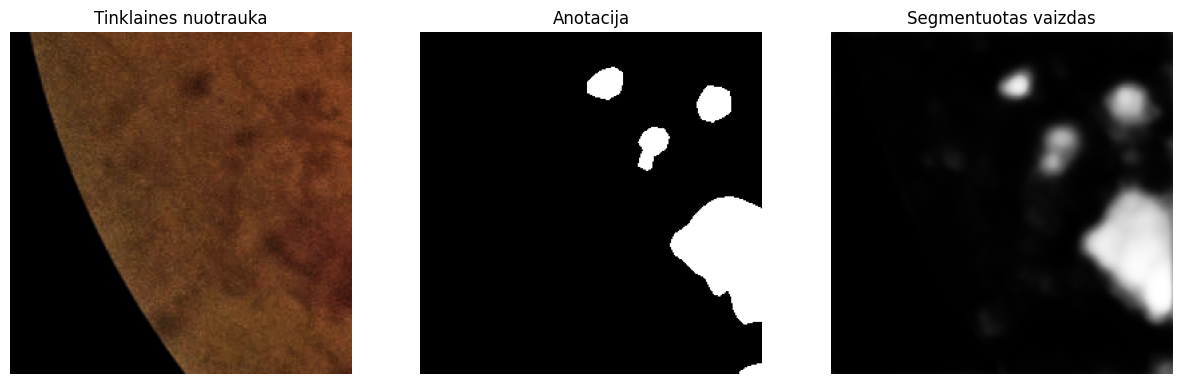

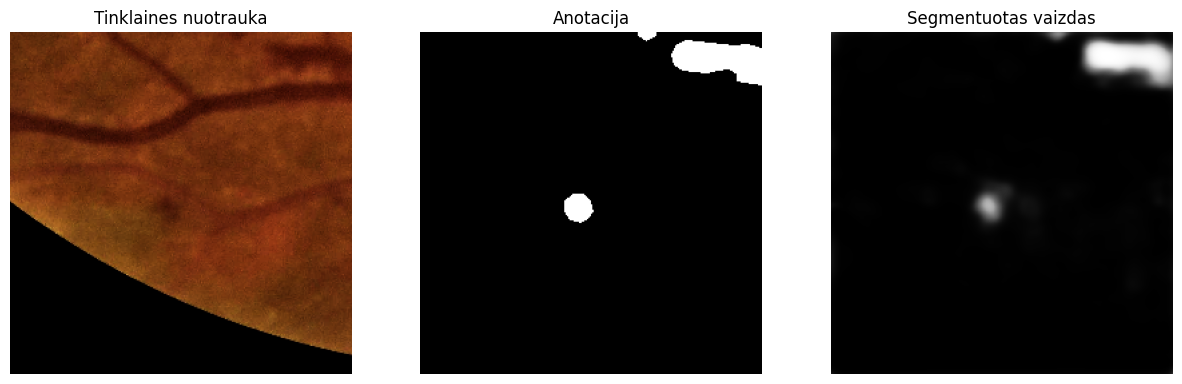

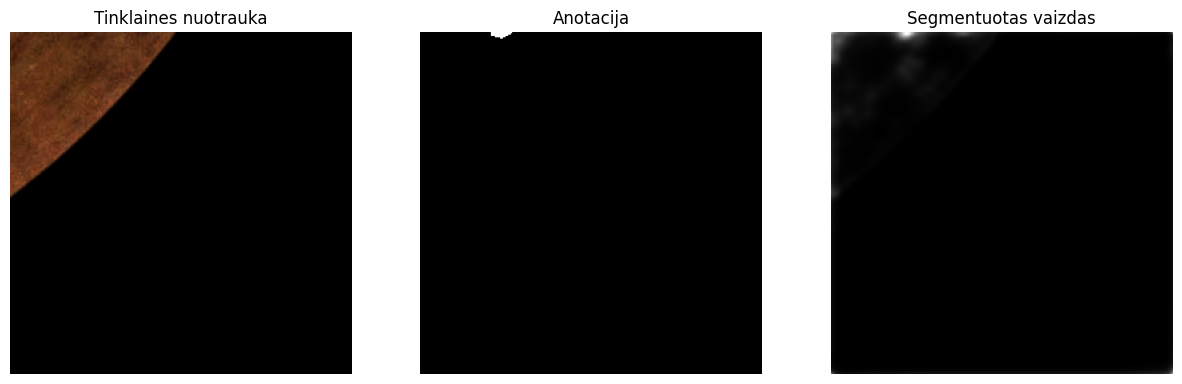

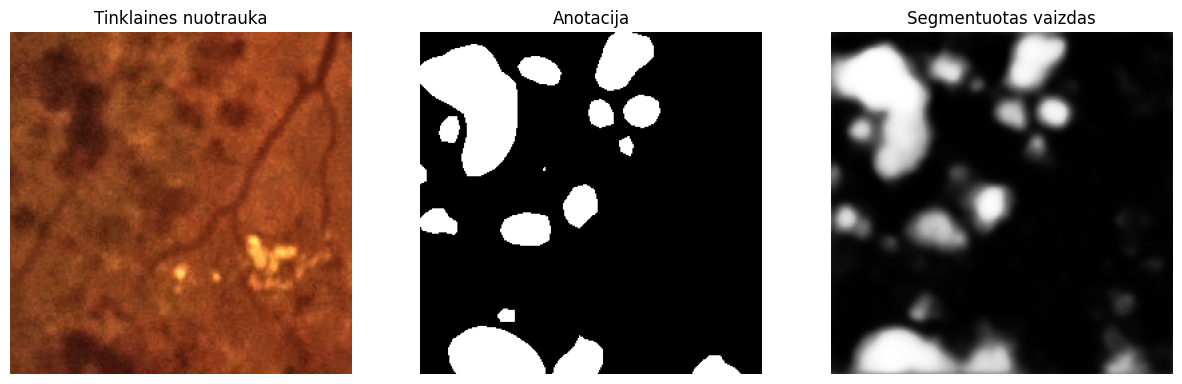

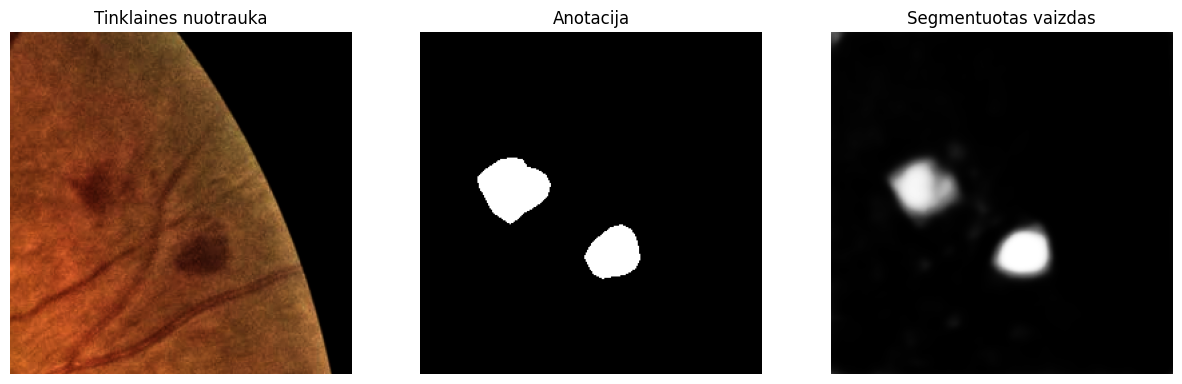

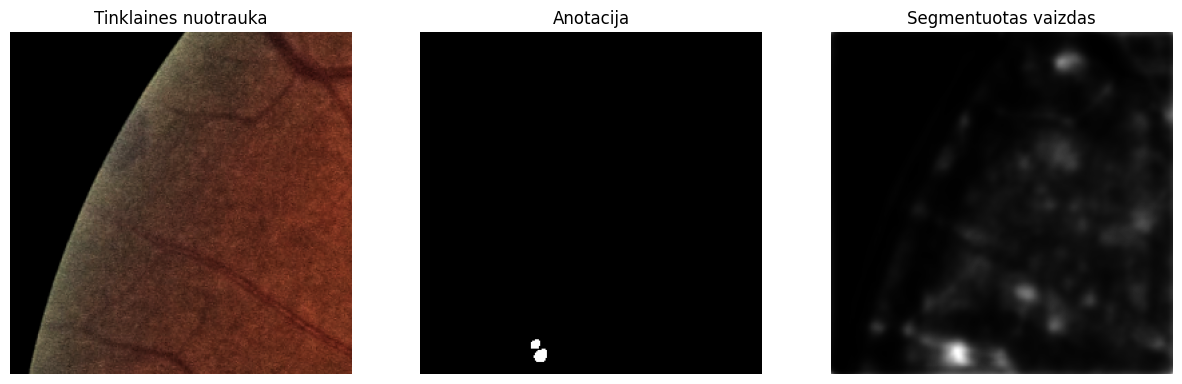

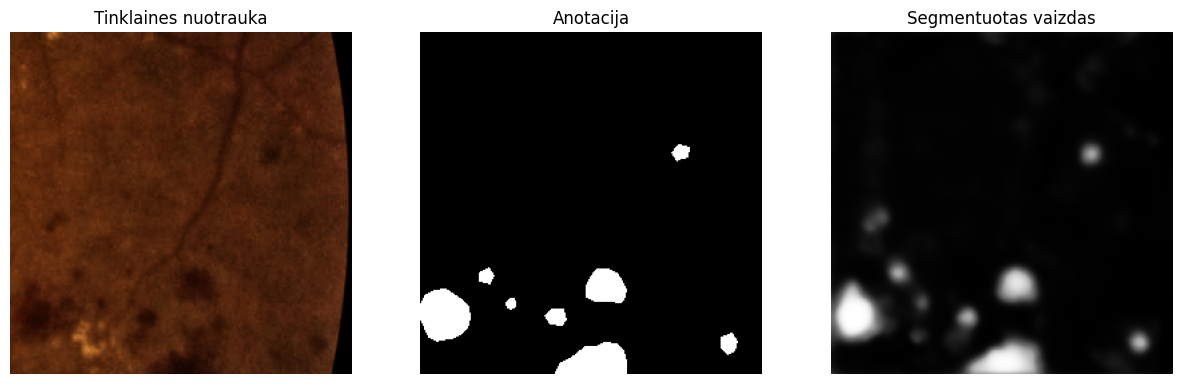

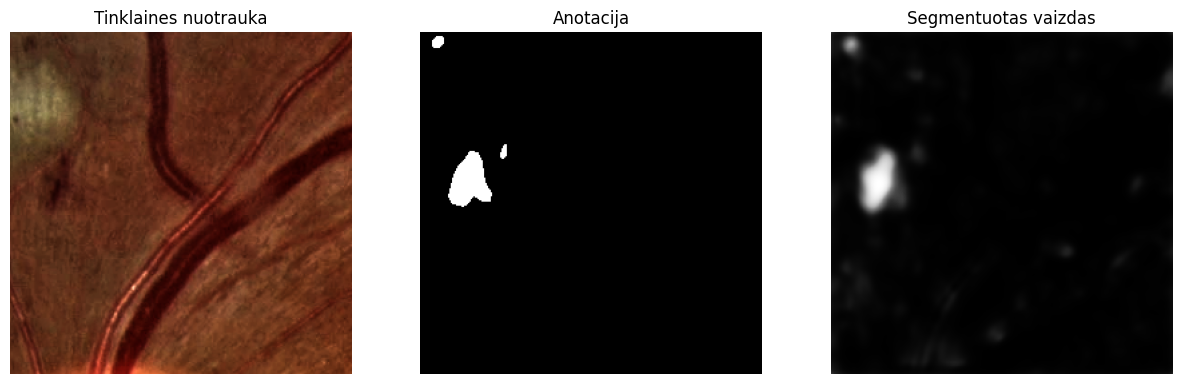

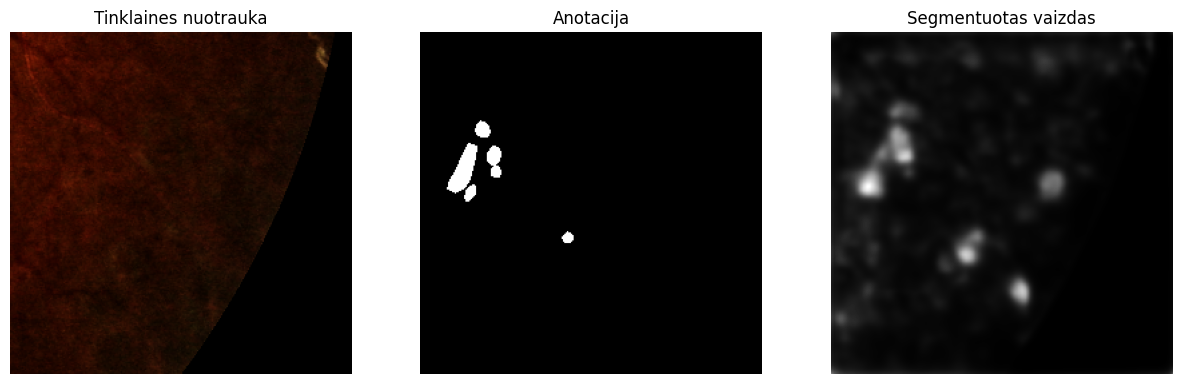

In [7]:
import numpy as np

current_loss = "focal"
model = att_unet(img_h=256, img_w=256, n_label = 1);
model.compile(optimizer = Adam(lr = 1e-4), loss = tasm.losses.DiceLoss(), metrics = ['accuracy', tasm.metrics.FScore(), tasm.metrics.IOUScore()])
model.load_weights("./attention-unet-weights/" +  current_loss + "/best_weights.hdf5")

scores = model.evaluate(testDataset)
print("Loss: {:.5}".format(scores[0]))
for metric, value in zip(["accuracy", tasm.metrics.FScore(), tasm.metrics.IOUScore()], scores[1:]):
    if metric != "accuracy":
        metric = metric.__name__
    print("mean {}: {:.5}".format(metric, value))
    
def displayPrediction(display_list, extra_title=''):
    plt.figure(figsize=(15, 15))
    title = ['Tinklaines nuotrauka', 'Anotacija', 'Segmentuotas vaizdas']

    if len(display_list) > len(title):
        title.append(extra_title)

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(display_list[i], cmap='gray')
        plt.axis('off')
    
    plt.show()
    
def create_mask(pred_mask):
    return pred_mask[0]

for image, mask in trainDataset.take(30):
    pred_mask = model.predict(image)
    pred_mask = create_mask(pred_mask)
    if pred_mask.max() != 0:
        displayPrediction([np.moveaxis(image[0], 0, 2),np.moveaxis(mask[0], 0, 2), np.moveaxis(pred_mask, 0, 2)])